In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ammarnassanalhajali/pklot-dataset/README.dataset.txt
/kaggle/input/datasets/ammarnassanalhajali/pklot-dataset/README.roboflow.txt
/kaggle/input/datasets/ammarnassanalhajali/pklot-dataset/valid/2012-12-22_19_20_16_jpg.rf.5488350455fd1ae49f8864d2027e4161.jpg
/kaggle/input/datasets/ammarnassanalhajali/pklot-dataset/valid/2012-12-17_19_10_17_jpg.rf.dedc5abadf410484ae957efc1c8d7847.jpg
/kaggle/input/datasets/ammarnassanalhajali/pklot-dataset/valid/2012-11-10_19_08_15_jpg.rf.053a483a74f05e267cfde918f4ecdbab.jpg
/kaggle/input/datasets/ammarnassanalhajali/pklot-dataset/valid/2013-02-26_14_09_34_jpg.rf.1c68296bb19f349e6a989194eb4cb21a.jpg
/kaggle/input/datasets/ammarnassanalhajali/pklot-dataset/valid/2012-12-17_17_05_14_jpg.rf.ff88879b8321072dee28ca04a2e64d5b.jpg
/kaggle/input/datasets/ammarnassanalhajali/pklot-dataset/valid/2013-03-12_08_55_03_jpg.rf.db52dac23e3fd36aefc8e4c5ccf88e73.jpg
/kaggle/input/datasets/ammarnassanalhajali/pklot-dataset/valid/2013-03-03_17_15_13_jp

In [1]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.8 MB/s eta 0:00:00


In [6]:
# ── CELL 2: Convert COCO annotations to YOLO format ─────────
import json
import shutil
from pathlib import Path
from collections import defaultdict

RAW_DIR = Path("/kaggle/input/datasets/ammarnassanalhajali/pklot-dataset")
OUT_DIR = Path("/kaggle/working/dataset")

CATEGORY_MAP = {1: 0, 2: 1}   # 1=space-empty->0, 2=space-occupied->1
CLASS_NAMES  = ["empty", "occupied"]


def coco_to_yolo(bbox, img_w, img_h):
    x, y, w, h = bbox
    cx = (x + w / 2) / img_w
    cy = (y + h / 2) / img_h
    return cx, cy, w / img_w, h / img_h


def convert_split(src_dir, img_dst, lbl_dst):
    img_dst.mkdir(parents=True, exist_ok=True)
    lbl_dst.mkdir(parents=True, exist_ok=True)

    with open(src_dir / "_annotations.coco.json") as f:
        coco = json.load(f)

    id_to_file = {i["id"]: i["file_name"] for i in coco["images"]}
    id_to_size = {i["id"]: (i["width"], i["height"]) for i in coco["images"]}

    ann_by_img = defaultdict(list)
    for ann in coco["annotations"]:
        if ann["category_id"] in CATEGORY_MAP:
            ann_by_img[ann["image_id"]].append(ann)

    count = 0
    for img_id, anns in ann_by_img.items():
        fname = id_to_file[img_id]
        img_w, img_h = id_to_size[img_id]
        src_img = src_dir / fname
        if not src_img.exists():
            continue
        lines = []
        for ann in anns:
            cls = CATEGORY_MAP[ann["category_id"]]
            cx, cy, w, h = coco_to_yolo(ann["bbox"], img_w, img_h)
            cx, cy = max(0, min(1, cx)), max(0, min(1, cy))
            w,  h  = max(0, min(1, w)),  max(0, min(1, h))
            lines.append(f"{cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
        shutil.copy2(src_img, img_dst / fname)
        (lbl_dst / (Path(fname).stem + ".txt")).write_text("\n".join(lines))
        count += 1
    return count

print("Converting train split...")
n_train = convert_split(RAW_DIR / "train", OUT_DIR / "images/train", OUT_DIR / "labels/train")
print(f"  {n_train} images")

print("Converting val split...")
n_val = convert_split(RAW_DIR / "valid", OUT_DIR / "images/val", OUT_DIR / "labels/val")
print(f"  {n_val} images")

data_yaml = OUT_DIR / "data.yaml"
data_yaml.write_text(
    f"path: {OUT_DIR}\ntrain: images/train\nval: images/val\nnc: 2\nnames: {CLASS_NAMES}\n"
)
print(f"\ndata.yaml written. Ready to train.")

Converting train split...
  8502 images
Converting val split...
  2424 images

data.yaml written. Ready to train.


In [7]:
# ── CELL 3: Train ────────────────────────────────────────────
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data=str(data_yaml),
    epochs=50,
    batch=64,          # 2x T4 can handle larger batches
    imgsz=640,
    device=[0, 1],     # both T4 GPUs
    workers=4,
    patience=10,
    cos_lr=True,
    project="/kaggle/working/runs",
    name="pklot_parking",
    save=True,
    plots=True,
)

print("\nTraining complete!")
print("Weights saved to: /kaggle/working/runs/pklot_parking/weights/best.pt")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=No


image 1/1 /kaggle/working/dataset/images/val/2012-10-26_15_44_53_jpg.rf.28e974ba6b6a955221b69a642b95d7b1.jpg: 640x640 15 emptys, 85 occupieds, 16.2ms
Speed: 2.9ms preprocess, 16.2ms inference, 25.5ms postprocess per image at shape (1, 3, 640, 640)
Empty: 15  |  Occupied: 85


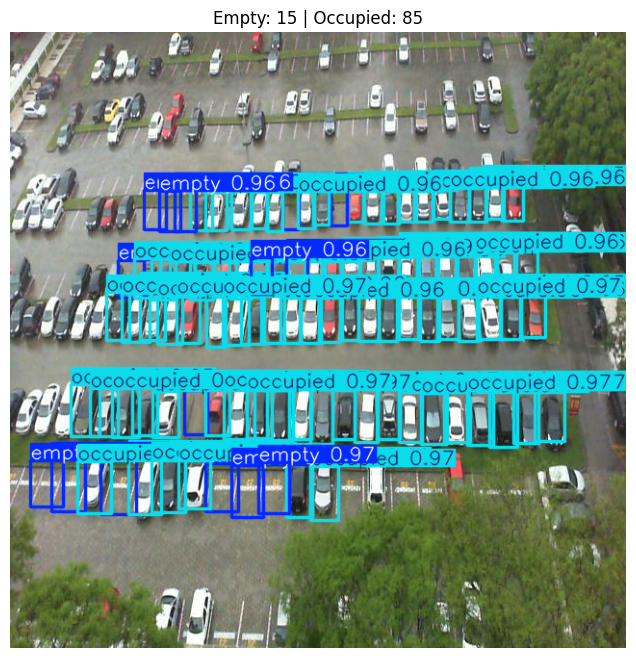

In [8]:
# ── CELL 4: Quick test on a validation image ─────────────────
import glob
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

best_weights = "/kaggle/working/runs/pklot_parking/weights/best.pt"
model = YOLO(best_weights)

# grab a random val image
val_images = glob.glob(str(OUT_DIR / "images/val/*.jpg"))
test_img = val_images[0]

results = model.predict(test_img, conf=0.3, save=False)
r = results[0]

n_empty    = int((r.boxes.cls == 0).sum())
n_occupied = int((r.boxes.cls == 1).sum())
print(f"Empty: {n_empty}  |  Occupied: {n_occupied}")

img = r.plot()   # annotated image as numpy array
plt.figure(figsize=(12, 8))
plt.imshow(img[:, :, ::-1])
plt.axis("off")
plt.title(f"Empty: {n_empty} | Occupied: {n_occupied}")
plt.show()


In [9]:
from IPython.display import FileLink
FileLink('/kaggle/working/runs/pklot_parking/weights/best.pt')

/kaggle/working/runs/pklot_parking/weights/best.pt